In [12]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings("ignore")

from tqdm import tqdm
import pandas as pd
tqdm.pandas()

from langdetect import detect, DetectorFactory

# Para que la detección de idioma sea reproducible
DetectorFactory.seed = 42

RANDOM_SEED = 42

# COFIGURACIÓN GENERAL
ROOT_PATH = r'C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration'

# --- Rutas de entrada ---
DATA_PATH_TOP_10     = ROOT_PATH + r'\dataset\arxiv_cs_top10.parquet'
DATA_PATH_ARTICULOS_UAM     = ROOT_PATH + r'\dataset\Articulos.csv'
# --- Rutas de salida ---
DATA_PATH_TOP_10_LIMPIO_BAELINE = ROOT_PATH + r'\dataset\arxiv_cs_top10_limpieza_baseline_run2.parquet'
DIR_MODELS = ROOT_PATH + r'\models'
DIR_RESULTADOS = ROOT_PATH + r'\resultados'

#os.makedirs(DIR_MODELS, exist_ok = True)
#os.makedirs(DIR_RESULTADOS, exist_ok = True)


# now = datetime.now() # Obtener la fecha y hora actual
# date_time = now.strftime("%d_%m_%Y_%H_%M_%S")

# OUTPUT_DIR        = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\res_' + date_time

# os.mkdir(OUTPUT_DIR)

# BEST_MODEL_PATH   = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\models\best_model_' + date_time + '.pt'
# CSV_HISTORY       = OUTPUT_DIR + r'\training_history_' + date_time + '.csv'
# CSV_OPTUNA        = OUTPUT_DIR + r'\optuna_results_' + date_time + '.csv'
# PLOT_CURVES       = OUTPUT_DIR + r'\curvas_entrenamiento_' + date_time + '.png'
# PLOT_CONFUSION    = OUTPUT_DIR + r'\confusion_matrix_' + date_time + '.png'





## Preprocesamiento de texto
Limpiar los abstracts antes de vectorizar:

- [x] Convertir a minúsculas.
- [x] Eliminar caracteres especiales, números sueltos y puntuación.
- [x] Eliminar stopwords en inglés.
- [x] Aplicar lematización 



In [13]:
# Carga del Dataset
df_top10 = pd.read_parquet(DATA_PATH_TOP_10)
print("Dataset cargado: OK!")


def limpieza_baseline(text):
    if not isinstance(text, str) or len(text) < 5:
        return ""
    text = text.lower()
    # URLs y correos
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S*@\S*\s?', '', text)
    # Eliminación de fórmulas matemáticas en LaTeX
    text = re.sub(r'\$.*?\$', '', text)
    # Eliminación de comandos y macros de LaTeX
    text = re.sub(r'\\[a-zA-Z]+\{.*?\}', '', text)
    # Solo letras y espacios
    text = re.sub(r'[^a-z\s]', '', text)
    # Normalización de espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Iniciando limpieza... Puede demorar unos minutos")

# Aplicar limpieza sobre el abstract
df_top10['texto_limpio'] = df_top10['abstract'].progress_apply(limpieza_baseline)

# Conservar solo columnas relevantes
df_top10 = df_top10[['title', 'abstract', 'cs_primary', 'texto_limpio']]

# Guardar el DF
df_top10.to_parquet(DATA_PATH_TOP_10_LIMPIO_BAELINE)
print("Limpieza completada y guardada: OK!")

Dataset cargado: OK!
Iniciando limpieza... Puede demorar unos minutos


100%|█████████████████████████████████████████████████████████████| 642077/642077 [00:45<00:00, 13970.51it/s]


Limpieza completada y guardada: OK!


In [14]:
df_top10

,title,abstract,cs_primary,texto_limpio
1,A limit relation for entropy and channel capac...,"In a quantum mechanical model, Diosi, Feldma...",cs.IT,in a quantum mechanical model diosi feldmann a...
4,On-line Viterbi Algorithm and Its Relationship...,"In this paper, we introduce the on-line Vite...",cs.DS,in this paper we introduce the online viterbi ...
6,Sparsely-spread CDMA - a statistical mechanics...,"Sparse Code Division Multiple Access (CDMA),...",cs.IT,sparse code division multiple access cdma a va...
9,Capacity of a Multiple-Antenna Fading Channel ...,Given a multiple-input multiple-output (MIMO...,cs.IT,given a multipleinput multipleoutput mimo chan...
12,On Punctured Pragmatic Space-Time Codes in Blo...,This paper considers the use of punctured co...,cs.IT,this paper considers the use of punctured conv...
...,...,...,...,...
892968,A Quick Glance at Quantum Cryptography,The recent application of the principles of ...,cs.CR,the recent application of the principles of qu...
892978,A simple proof of the unconditional security o...,Quantum key distribution is the most well-kn...,cs.CR,quantum key distribution is the most wellknown...
892984,Secure Classical Bit Commitment using Fixed Ca...,If mutually mistrustful parties A and B cont...,cs.CR,if mutually mistrustful parties a and b contro...
892989,Unconditionally Secure Commitment of a Certifi...,In a secure bit commitment protocol involvin...,cs.CR,in a secure bit commitment protocol involving ...


## Entranamiento

In [15]:
# Carga del corpus limpio 
df = pd.read_parquet(DATA_PATH_TOP_10_LIMPIO_BAELINE)
print(f"Registros cargados : {len(df):,}")
print(f"Clases disponibles : {df['cs_primary'].nunique()}")
print(df['cs_primary'].value_counts())

Registros cargados : 642,077
Clases disponibles : 10
cs_primary
cs.LG    163515
cs.CV    158670
cs.CL     80665
cs.IT     46983
cs.AI     46299
cs.RO     38704
cs.CR     33652
cs.SY     26912
cs.NA     26775
cs.DS     19902
Name: count, dtype: int64


In [16]:
# División train / validation 
X = df['texto_limpio'].fillna("")
y = df['cs_primary']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Train : {len(X_train):,} documentos")
print(f"Val   : {len(X_val):,} documentos")

Train : 513,661 documentos
Val   : 128,416 documentos


In [17]:
# Pesos de clase calculados sobre el conjunto de entrenamiento
clases      = y_train.unique()
K           = len(clases)
N_total     = len(y_train)
conteos     = y_train.value_counts()

pesos = {clase: N_total / (K * conteos[clase]) for clase in clases}

print("Pesos de clase:")
for clase, peso in sorted(pesos.items(), key=lambda x: x[1], reverse=True):
    print(f"  {clase:10s}  n={conteos[clase]:>7,}  peso={peso:.4f}")

Pesos de clase:
  cs.DS       n= 15,922  peso=3.2261
  cs.NA       n= 21,420  peso=2.3980
  cs.SY       n= 21,530  peso=2.3858
  cs.CR       n= 26,921  peso=1.9080
  cs.RO       n= 30,963  peso=1.6590
  cs.AI       n= 37,039  peso=1.3868
  cs.IT       n= 37,586  peso=1.3666
  cs.CL       n= 64,532  peso=0.7960
  cs.CV       n=126,936  peso=0.4047
  cs.LG       n=130,812  peso=0.3927


In [18]:
# Vectorización TF-IDF 
vectorizer = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),       # unigramas + bigramas
    sublinear_tf=True,        # escala logarítmica en frecuencias
    min_df=2,                 # ignorar términos en menos de 2 docs
    stop_words='english'      # stopwords 
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)

print(f"Dimensión matriz TF-IDF train : {X_train_tfidf.shape}")
print(f"Dimensión matriz TF-IDF val   : {X_val_tfidf.shape}")

Dimensión matriz TF-IDF train : (513661, 50000)
Dimensión matriz TF-IDF val   : (128416, 50000)


In [19]:
# Entrenamiento Regresión Logística
model = LogisticRegression(
    class_weight=pesos,    # compensar desbalance
    max_iter=1000,
    C=1.0,
    solver='saga',         # eficiente para corpus grandes
    random_state=RANDOM_SEED,
    n_jobs=-1              # usar todos los núcleos disponibles
)

print("Entrenando modelo...")
model.fit(X_train_tfidf, y_train)
print("Entrenamiento completado.")

Entrenando modelo...
Entrenamiento completado.


In [20]:
# Evaluación interna sobre validación arXiv 
y_pred_val = model.predict(X_val_tfidf)

print("=" * 60)
print("EVALUACIÓN INTERNA — Validación arXiv (20%)")
print("=" * 60)
print(classification_report(y_val, y_pred_val, digits=4))

macro_f1_val = f1_score(y_val, y_pred_val, average='macro')
print(f"Macro F1 validación arXiv : {macro_f1_val:.4f}")

EVALUACIÓN INTERNA — Validación arXiv (20%)
              precision    recall  f1-score   support

       cs.AI     0.4808    0.5707    0.5219      9260
       cs.CL     0.8332    0.8674    0.8500     16133
       cs.CR     0.7903    0.8896    0.8370      6731
       cs.CV     0.9135    0.8678    0.8900     31734
       cs.DS     0.7461    0.9126    0.8210      3980
       cs.IT     0.8659    0.8909    0.8782      9397
       cs.LG     0.8429    0.7064    0.7686     32703
       cs.NA     0.7835    0.9160    0.8446      5355
       cs.RO     0.8066    0.8792    0.8413      7741
       cs.SY     0.7134    0.8302    0.7674      5382

    accuracy                         0.8106    128416
   macro avg     0.7776    0.8331    0.8020    128416
weighted avg     0.8188    0.8106    0.8118    128416

Macro F1 validación arXiv : 0.8020


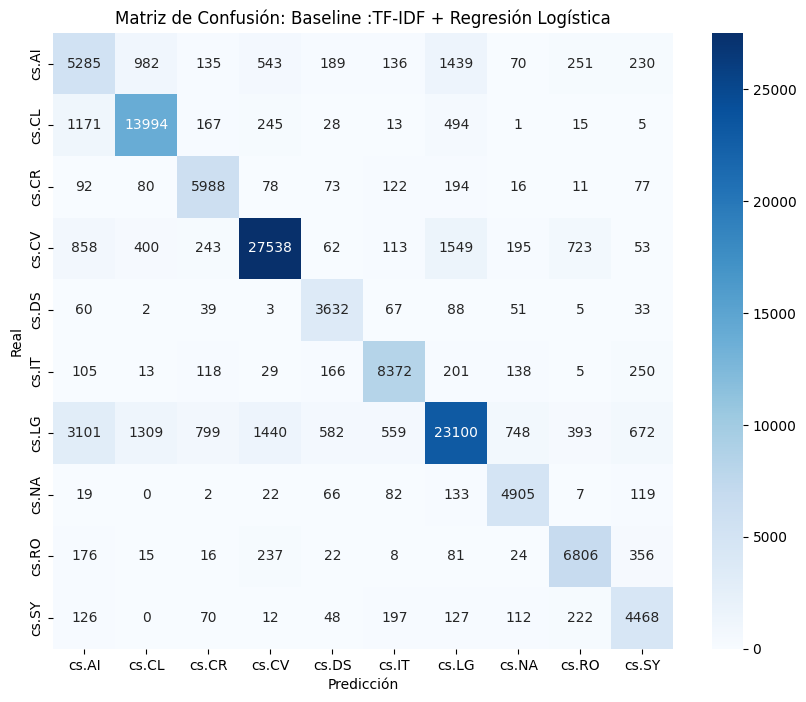

In [21]:
# Matriz de Confusión 
etiquetas = model.classes_

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_pred_val, labels = etiquetas), annot=True, fmt='d', cmap='Blues', xticklabels=etiquetas, yticklabels=etiquetas)
plt.title('Matriz de Confusión: Baseline :TF-IDF + Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [22]:
# Evaluación transferencia pura sobre UAM-A 

# Cargar el dataset UAM-A
df_uam = pd.read_csv(DATA_PATH_ARTICULOS_UAM)   


def limpieza_baseline(text):
    # Detección de Idioma (Filtro inicial)
    try:
        if detect(text) != 'en':
            return ""
    except:
        return ""
        
    if not isinstance(text, str) or len(text) < 5:
        return ""
    text = text.lower()
    # URLs y correos
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S*@\S*\s?', '', text)
    # Eliminación de fórmulas matemáticas en LaTeX
    text = re.sub(r'\$.*?\$', '', text)
    # Eliminación de comandos y macros de LaTeX
    text = re.sub(r'\\[a-zA-Z]+\{.*?\}', '', text)
    # Solo letras y espacios
    text = re.sub(r'[^a-z\s]', '', text)
    # Normalización de espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Aplicar la misma limpieza ligera usada en el corpus arXiv
df_uam['texto_limpio'] = df_uam['Resumen'].apply(limpieza_baseline)

# Eliminar las filas que quedaron vacías por el filtro de idioma
df_uam = df_uam[df_uam['texto_limpio'] != ""].reset_index(drop=True)

# Vectorizar con el TF-IDF 
X_uam_tfidf = vectorizer.transform(df_uam['texto_limpio'].fillna(""))

print(f"Documentos UAM-A vectorizados: {X_uam_tfidf.shape[0]:,}")

Documentos UAM-A vectorizados: 746


In [23]:
df_uam

,Resumen,texto_limpio
0,Self stabilization effects were experimentally...,self stabilization effects were experimentally...
1,The current work on stellarators being carried...,the current work on stellarators being carried...
2,We prove that a graph is 4-colorable if and on...,we prove that a graph is colorable if and only...
3,Trapped electron modes in stellarators can be ...,trapped electron modes in stellarators can be ...
4,This paper contains viewgraphs on the existenc...,this paper contains viewgraphs on the existenc...
...,...,...
741,Topic discovery is finding the main idea of la...,topic discovery is finding the main idea of la...
742,This study examines the release kinetics of hy...,this study examines the release kinetics of hy...
743,A layer of sheared poloidal velocity (or radia...,a layer of sheared poloidal velocity or radial...
744,The studies of MHD stability properties of ste...,the studies of mhd stability properties of ste...


In [24]:
# Predicciones sobre UAM-A
y_pred_uam = model.predict(X_uam_tfidf)

# Guardar predicciones en el DataFrame
df_uam['pred_baseline'] = y_pred_uam

print("Distribución de predicciones sobre UAM-A:")
print(pd.Series(y_pred_uam).value_counts().to_string())

Distribución de predicciones sobre UAM-A:
cs.AI    280
cs.NA    141
cs.SY    105
cs.CL     61
cs.DS     58
cs.CV     32
cs.CR     25
cs.LG     22
cs.IT     14
cs.RO      8


In [25]:
df_uam

,Resumen,texto_limpio,pred_baseline
0,Self stabilization effects were experimentally...,self stabilization effects were experimentally...,cs.NA
1,The current work on stellarators being carried...,the current work on stellarators being carried...,cs.CL
2,We prove that a graph is 4-colorable if and on...,we prove that a graph is colorable if and only...,cs.DS
3,Trapped electron modes in stellarators can be ...,trapped electron modes in stellarators can be ...,cs.LG
4,This paper contains viewgraphs on the existenc...,this paper contains viewgraphs on the existenc...,cs.NA
...,...,...,...
741,Topic discovery is finding the main idea of la...,topic discovery is finding the main idea of la...,cs.CL
742,This study examines the release kinetics of hy...,this study examines the release kinetics of hy...,cs.NA
743,A layer of sheared poloidal velocity (or radia...,a layer of sheared poloidal velocity or radial...,cs.NA
744,The studies of MHD stability properties of ste...,the studies of mhd stability properties of ste...,cs.NA


In [30]:
df_uam.to_csv(DIR_RESULTADOS + r'\predicciones_uam_baseline_sin_aug.csv')

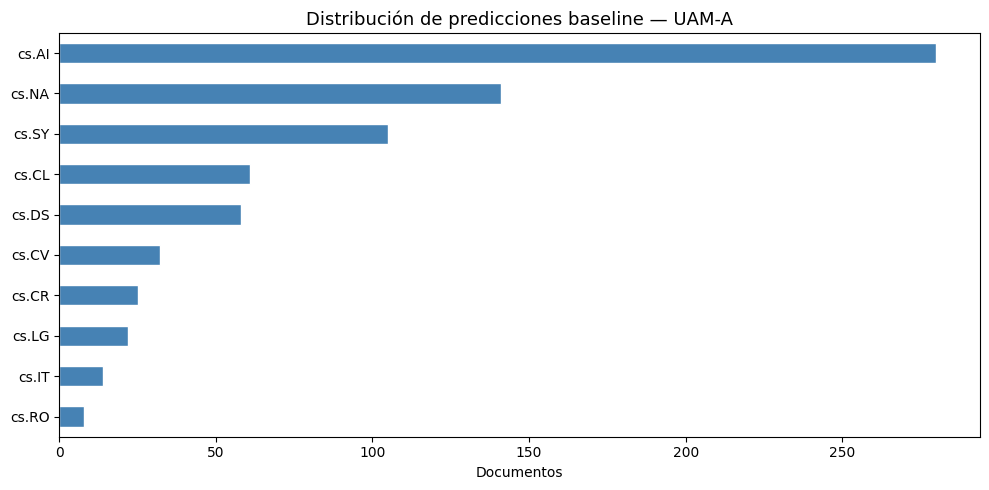

In [27]:
# Métricas UAM-A 

# y_true_uam = df_uam['etiqueta_manual']
# print("=" * 60)
# print("EVALUACIÓN TRANSFERENCIA PURA — UAM-A (733 docs)")
# print("=" * 60)
# print(classification_report(y_true_uam, y_pred_uam, digits=4))
# macro_f1_uam = f1_score(y_true_uam, y_pred_uam, average='macro')
# print(f"Macro F1 UAM-A : {macro_f1_uam:.4f}")

# Solo la distribución de predicciones
fig, ax = plt.subplots(figsize=(10, 5))
pd.Series(y_pred_uam).value_counts().sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Distribución de predicciones baseline — UAM-A", fontsize=13)
ax.set_xlabel("Documentos")
plt.tight_layout()
plt.savefig(DIR_RESULTADOS + "pred_baseline_uam.png", dpi=150)
plt.show()

In [28]:
# ─── Guardar modelo y vectorizador para comparación posterior ─────────────────
import joblib

joblib.dump(model,      DIR_MODELS + r'\baseline_logreg.pkl')
joblib.dump(vectorizer, DIR_MODELS + r'\baseline_tfidf.pkl')
print("Modelo y vectorizador guardados.")

Modelo y vectorizador guardados.


In [29]:
#  Guardar predicciones y métricas del baseline 
import json

#  Predicciones sobre UAM-A 
# 'con_aug'  → baseline entrenado sobre arxiv_cs_top10_augmented
# 'sin_aug'  → baseline entrenado sobre arxiv_cs_top10
sufijo = 'sin_aug'   

#  Métricas sobre validacion arXiv 
macro_f1_val  = f1_score(y_val, y_pred_val, average='macro',    zero_division=0)
macro_p_val   = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
macro_r_val   = recall_score(y_val, y_pred_val, average='macro',    zero_division=0)

# F1 por clase sobre validacion
f1_por_clase_val = f1_score(
    y_val, y_pred_val, average=None,
    labels=list(model.classes_), zero_division=0
)
f1_dict_val = dict(zip(model.classes_, f1_por_clase_val.tolist()))

#  Distribucion de predicciones sobre UAM-A 
dist_uam = dict(
    df_uam['pred_baseline'].value_counts().to_dict()
)

#  Construccion del diccionario de métricas 
metricas = {
    'version':             sufijo,
    'modelo':              'TF-IDF + Regresion Logistica',
    'vectorizador': {
        'max_features':    vectorizer.max_features,
        'ngram_range':     list(vectorizer.ngram_range),
        'sublinear_tf':    vectorizer.sublinear_tf,
        'min_df':          vectorizer.min_df,
        'stop_words':      'english',
    },
    'clasificador': {
        'C':               model.C,
        'max_iter':        model.max_iter,
        'solver':          model.solver,
        'class_weight':    'calculado',
    },
    'split': {
        'train_size':      0.80,
        'val_size':        0.20,
        'random_seed':     RANDOM_SEED,
        'stratify':        True,
    },
    'n_train':             len(X_train),
    'n_val':               len(X_val),
    'n_uam':               len(df_uam),
    'clases':              list(model.classes_),
    'pesos_clase':         {k: round(v, 4) for k, v in pesos.items()},
    'metricas_val_arxiv': {
        'macro_f1_val_arxiv':       round(macro_f1_val,  4),
        'macro_precision_val_arxiv': round(macro_p_val,  4),
        'macro_recall_val_arxiv':    round(macro_r_val,  4),
        'f1_por_clase':             {k: round(v, 4) for k, v in f1_dict_val.items()},
    },
    'distribucion_uam': dist_uam,
    'ground_truth_uam': False,
    'hallazgo_principal': 'Confusion cs.AI vs cs.LG — patron persistente en todos los modelos',
}

#  Guardar JSON de métricas
nombre_metricas = f'baseline{sufijo}_metrics.json'
with open(nombre_metricas, 'w', encoding='utf-8') as f:
    json.dump(metricas, f, ensure_ascii=False, indent=2)
print(f'Metricas guardadas: {nombre_metricas}')


#  Reporte final en pantalla 
print('\n' + '=' * 55)
print(f'RESUMEN BASELINE — {sufijo.upper()}')
print('=' * 55)
print(f'Macro F1 validacion arXiv : {macro_f1_val:.4f}')
print(f'Articulos UAM-A predichos : {len(df_uam):,}')
print(f'Archivos generados:')
print(f'  baseline{sufijo}_predictions_uam.parquet')
print(f'  baseline{sufijo}_metrics.json')
print('=' * 55)

Metricas guardadas: baselinesin_aug_metrics.json

RESUMEN BASELINE — SIN_AUG
Macro F1 validacion arXiv : 0.8020
Articulos UAM-A predichos : 746
Archivos generados:
  baselinesin_aug_predictions_uam.parquet
  baselinesin_aug_metrics.json
